# 03 - Extracción de Características: PCA vs Características Manuales

**Fase del Pipeline DSR: Transformación de Datos**

Este notebook compara dos representaciones de características para los modelos de clustering:
- **Ruta A (PCA de Señal):** Señal directa escalada + PCA reteniendo 95% de varianza
- **Ruta B (Características Manuales):** 22 características diseñadas a mano (16 base + 6 de ventana temporal)

El autoencoder usa la señal escalada completa de 200 dimensiones (Ruta A sin PCA).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from ecg_anomaly.config import SystemConfig
from ecg_anomaly.seeding import set_global_seed
from ecg_anomaly.cache import get_or_build_preprocessed
from ecg_anomaly.features.signal_pca import SignalPCAExtractor
from ecg_anomaly.features.manual import ManualFeatureExtractor, FEATURE_NAMES

sns.set_style("whitegrid")
config = SystemConfig.from_yaml("../config/default.yaml")
config.setup_logging()
set_global_seed(config.random_seed)

## 1. Cargar y Preprocesar Datos

In [2]:
preprocessed = get_or_build_preprocessed(config)

print(f"Input shape: {preprocessed.segments.shape}")
print(f"Labels: {preprocessed.labels.shape} (Normal={int(np.sum(preprocessed.labels==0)):,}, Anomalous={int(np.sum(preprocessed.labels==1)):,})")

[cache] Cargando preprocesamiento desde pp_lc0.5_hc40.0_ord4_b90_a110.joblib
Input shape: (100705, 200)
Labels: (100705,) (Normal=90,099, Anomalous=10,606)


## 1b. Split solo-normal (evita fuga de datos)

Para evitar *data leakage*, el `StandardScaler`/PCA de la Ruta A se ajusta **solo con latidos normales** y se aplica sobre todo el dataset. Así el autoencoder (y esta representación) aprenden cómo es un latido normal, y las anomalías se destacan por su error de reconstrucción/distancia, en vez de haber sido "vistas" durante el ajuste.

In [3]:
from ecg_anomaly.data.splitting import make_normal_fit_split

fit_idx, eval_idx = make_normal_fit_split(preprocessed, seed=config.random_seed)
print(f"Fit (solo normales): {len(fit_idx):,} latidos")
print(f"Eval (normales restantes + anomalias): {len(eval_idx):,} latidos")

Fit (solo normales): 72,079 latidos
Eval (normales restantes + anomalias): 28,626 latidos


## 2. Ruta A: PCA de Señal

StandardScaler + PCA con retención del 95% de varianza.
Esto reduce de 200 dimensiones a un número mucho menor de componentes principales.

In [4]:
pca_extractor = SignalPCAExtractor(
    variance_threshold=config.pca_variance_threshold, random_state=config.random_seed
)
pca_extractor.fit(preprocessed.segments[fit_idx])  # fit solo normales, evita fuga de datos
X_pca = pca_extractor.transform(preprocessed.segments)

print(f"Original dimensions: {preprocessed.segments.shape[1]}")
print(f"PCA components: {pca_extractor.n_components}")
print(f"Variance retained: {pca_extractor.explained_variance_ratio * 100:.1f}%")
print(f"Output shape: {X_pca.shape}")

18:32:22 [ecg_anomaly.features.signal_pca] INFO: PCA: 200 -> 13 componentes (95.7% varianza retenida)


Original dimensions: 200
PCA components: 13
Variance retained: 95.7%
Output shape: (100705, 13)


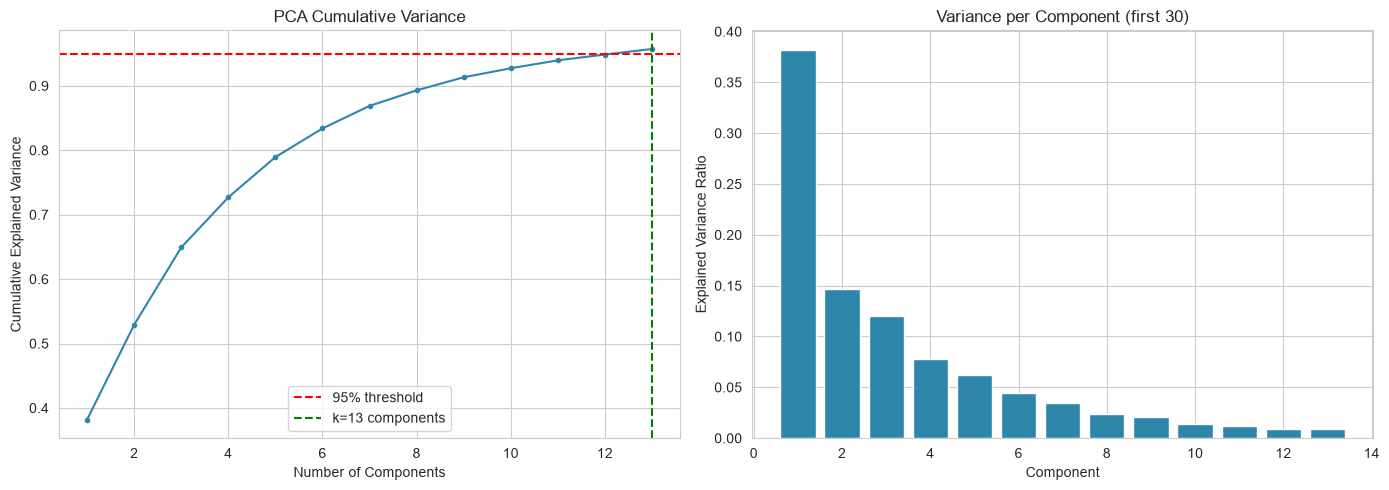

In [5]:
# Cumulative variance curve
cumvar = np.cumsum(pca_extractor.pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative variance
axes[0].plot(range(1, len(cumvar) + 1), cumvar, "o-", markersize=3, color="#2E86AB")
axes[0].axhline(config.pca_variance_threshold, color="red", linestyle="--",
                label=f"{config.pca_variance_threshold*100:.0f}% threshold")
axes[0].axvline(pca_extractor.n_components, color="green", linestyle="--",
                label=f"k={pca_extractor.n_components} components")
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].set_title("PCA Cumulative Variance")
axes[0].legend()

# Individual variance per component (first 30)
n_show = min(30, len(pca_extractor.pca.explained_variance_ratio_))
axes[1].bar(range(1, n_show + 1), pca_extractor.pca.explained_variance_ratio_[:n_show], color="#2E86AB")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Explained Variance Ratio")
axes[1].set_title("Variance per Component (first 30)")

plt.tight_layout()
plt.show()

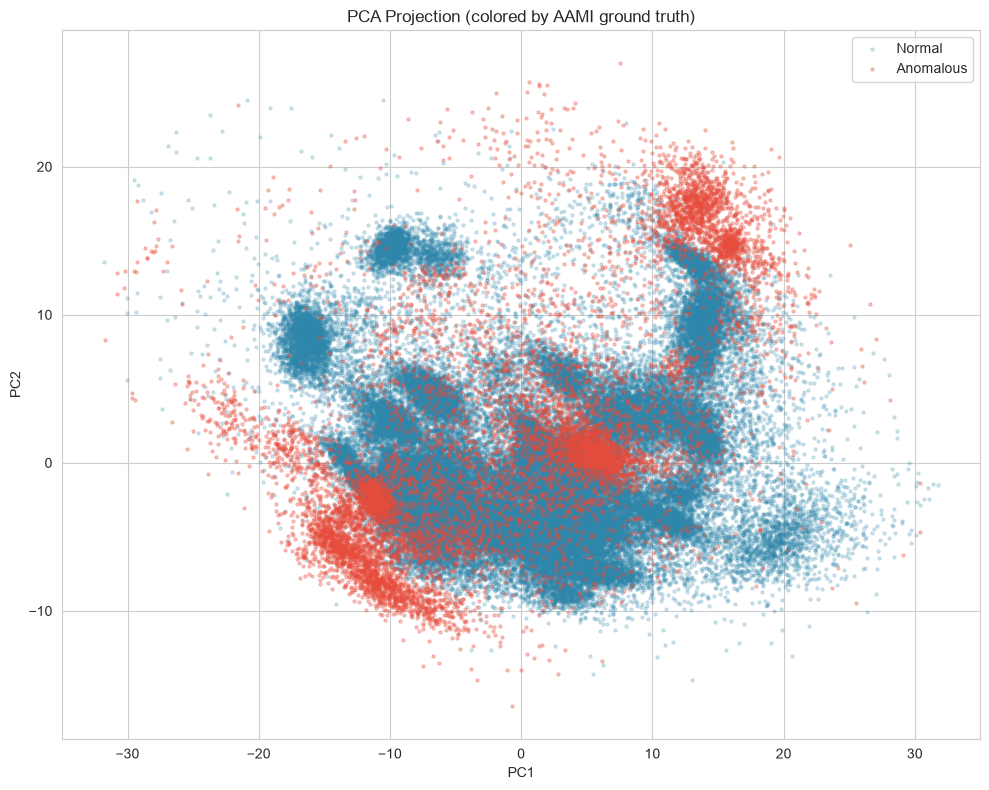

In [6]:
# PCA scatter: first two components colored by true label
fig, ax = plt.subplots(figsize=(10, 8))
normal_mask = preprocessed.labels == 0
anomaly_mask = preprocessed.labels == 1

ax.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1], alpha=0.2, s=5, c="#2E86AB", label="Normal")
ax.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1], alpha=0.3, s=5, c="#E74C3C", label="Anomalous")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA Projection (colored by AAMI ground truth)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Ruta B: Extracción de Características Manuales

Extrae 22 características por latido en 5 categorías:
- **Morfológicas (4):** Amplitud R, amplitud S, duración QRS, rango de amplitud
- **Temporales (3):** Intervalo RR, ratio RR, diferencia RR
- **Estadísticas (3):** Media, desv. estándar, curtosis
- **Espectrales (2):** Frecuencia dominante, energía espectral
- **Contexto RR (4):** RR antes/después, ratio RR pre/post, desviación RR
- **Ventana (6):** Media/desv. RR (5,10), RMSSD, PNN (ver sección 3b)

Total: 16 base + 6 de ventana = 22 características por latido.


In [7]:
manual_extractor = ManualFeatureExtractor()
X_manual = manual_extractor.extract(
    preprocessed.segments,
    preprocessed.r_peaks_flat,
    fs=config.sampling_rate,
)

print(f"Manual features shape: {X_manual.shape}")
print(f"Feature names: {FEATURE_NAMES}")

18:32:45 [ecg_anomaly.features.manual] INFO: Features manuales: 100705 latidos x 22 features


Manual features shape: (100705, 22)
Feature names: ['r_amplitude', 's_amplitude', 'qrs_duration', 'amplitude_range', 'rr_current', 'rr_ratio', 'rr_diff', 'mean', 'std', 'kurtosis', 'dominant_freq', 'spectral_energy', 'rr_pre', 'rr_post', 'rr_ratio_pre_post', 'rr_dev', 'rr_mean_5', 'rr_std_5', 'rr_mean_10', 'rr_std_10', 'rmssd_5', 'pnn_5']


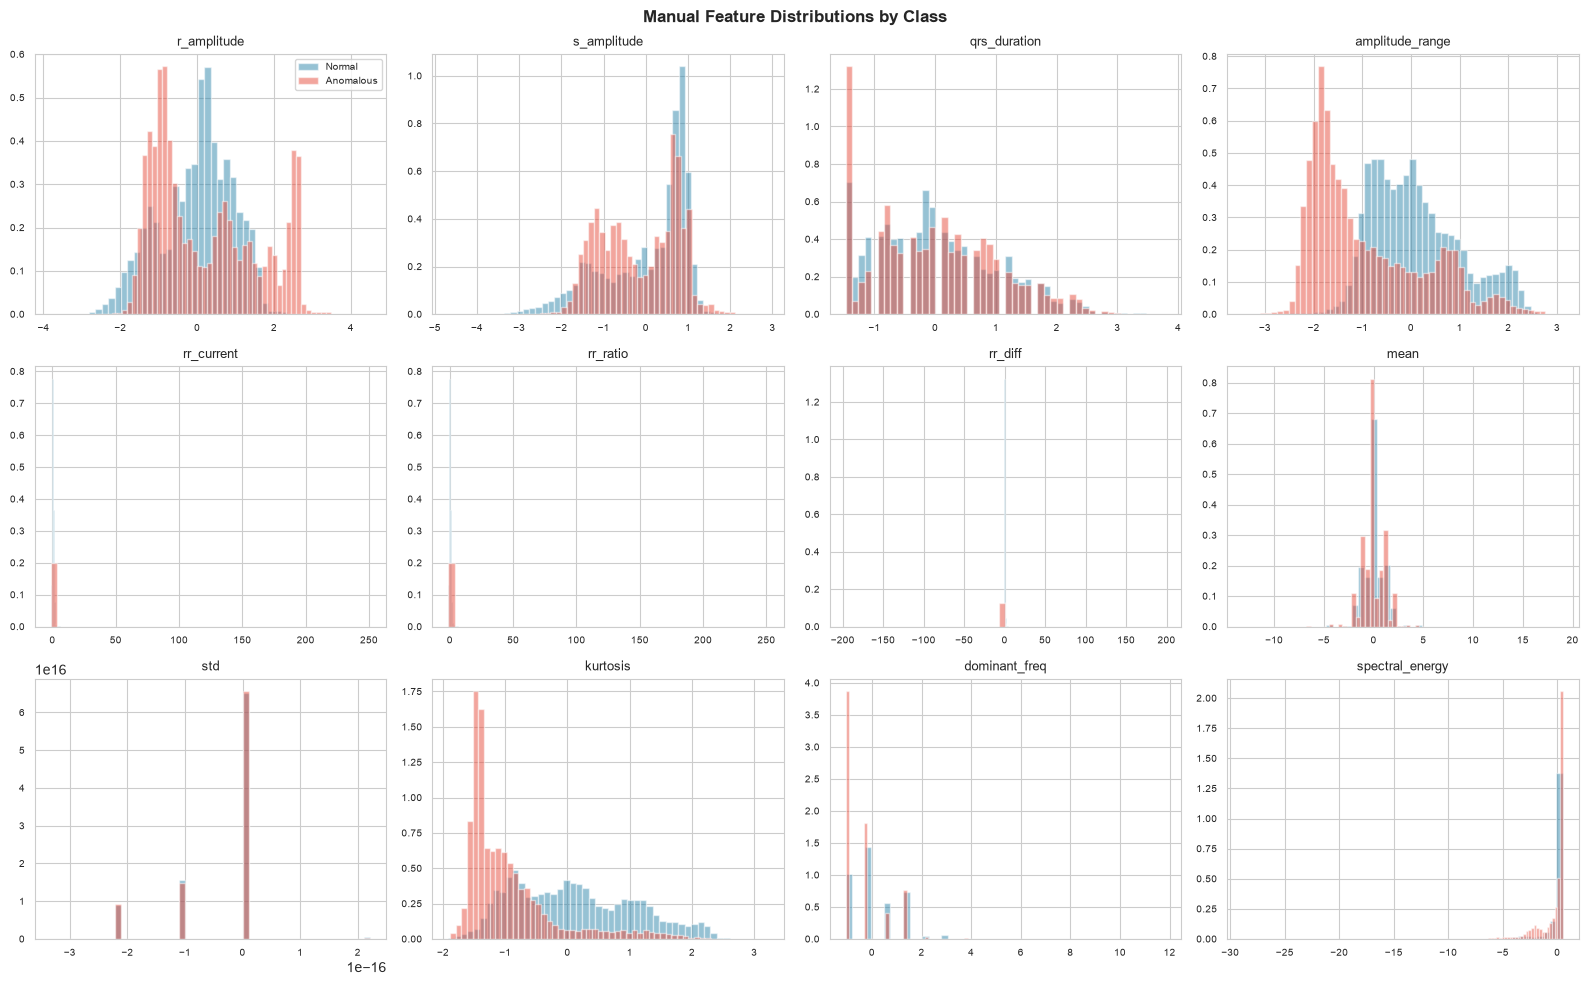

In [8]:
# Feature distributions: Normal vs Anomalous
df = pd.DataFrame(X_manual, columns=FEATURE_NAMES)
df["label"] = preprocessed.labels
df["class"] = df["label"].map({0: "Normal", 1: "Anomalous"})

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, feat in zip(axes.flat, FEATURE_NAMES):
    for label, color, name in [(0, "#2E86AB", "Normal"), (1, "#E74C3C", "Anomalous")]:
        vals = df[df["label"] == label][feat]
        ax.hist(vals, bins=50, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(feat, fontsize=9)
    ax.tick_params(labelsize=7)

axes[0, 0].legend(fontsize=7)
plt.suptitle("Manual Feature Distributions by Class", fontweight="bold")
plt.tight_layout()
plt.show()

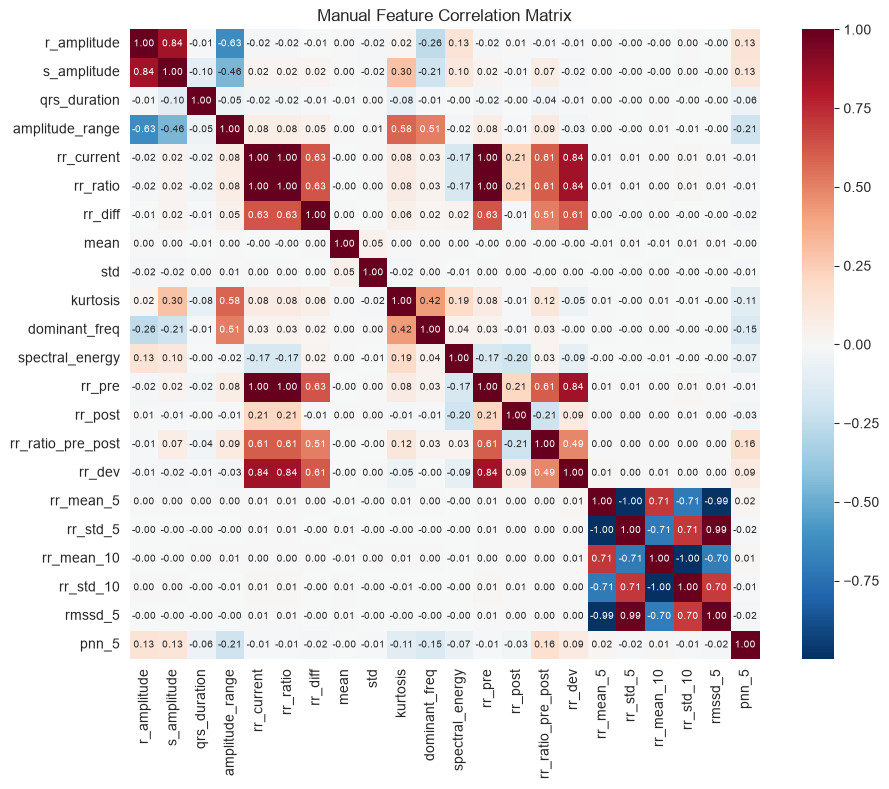

In [9]:
# Correlation matrix of manual features
fig, ax = plt.subplots(figsize=(10, 8))
corr = pd.DataFrame(X_manual, columns=FEATURE_NAMES).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=ax, annot_kws={"fontsize": 7})
ax.set_title("Manual Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 3b. Temporal Window Features (Fase 2)

Las arritmias cardíacas no son eventos aislados. Para capturar patrones como:

- **Bigeminia ventricular**: alternancia normal-anómalo-normal-anómalo...
- **Taquicardia ventricular sostenida**: ≥3 latidos anómalos consecutivos
- **Fibrilación auricular**: intervalos RR irregulares

se añadieron 6 features de ventana deslizante que analizan los últimos 5 y 10 latidos:

| Feature | Descripción | Ventana |
|---------|-------------|---------|
| `rr_mean_5` | Promedio de intervalos RR | últimos 5 latidos |
| `rr_std_5` | Desviación estándar de RR | últimos 5 latidos |
| `rr_mean_10` | Promedio de intervalos RR | últimos 10 latidos |
| `rr_std_10` | Desviación estándar de RR | últimos 10 latidos |
| `rmssd_5` | Raíz del cuadrado medio de diferencias sucesivas (variabilidad latido a latido) | últimos 5 latidos |
| `pnn_5` | Proporción de latidos con RR anormal en la ventana | últimos 5 latidos |

Estas features permiten que los modelos de clustering distingan patrones temporales,
mejorando la detección de arritmias que requieren contexto de múltiples latidos.

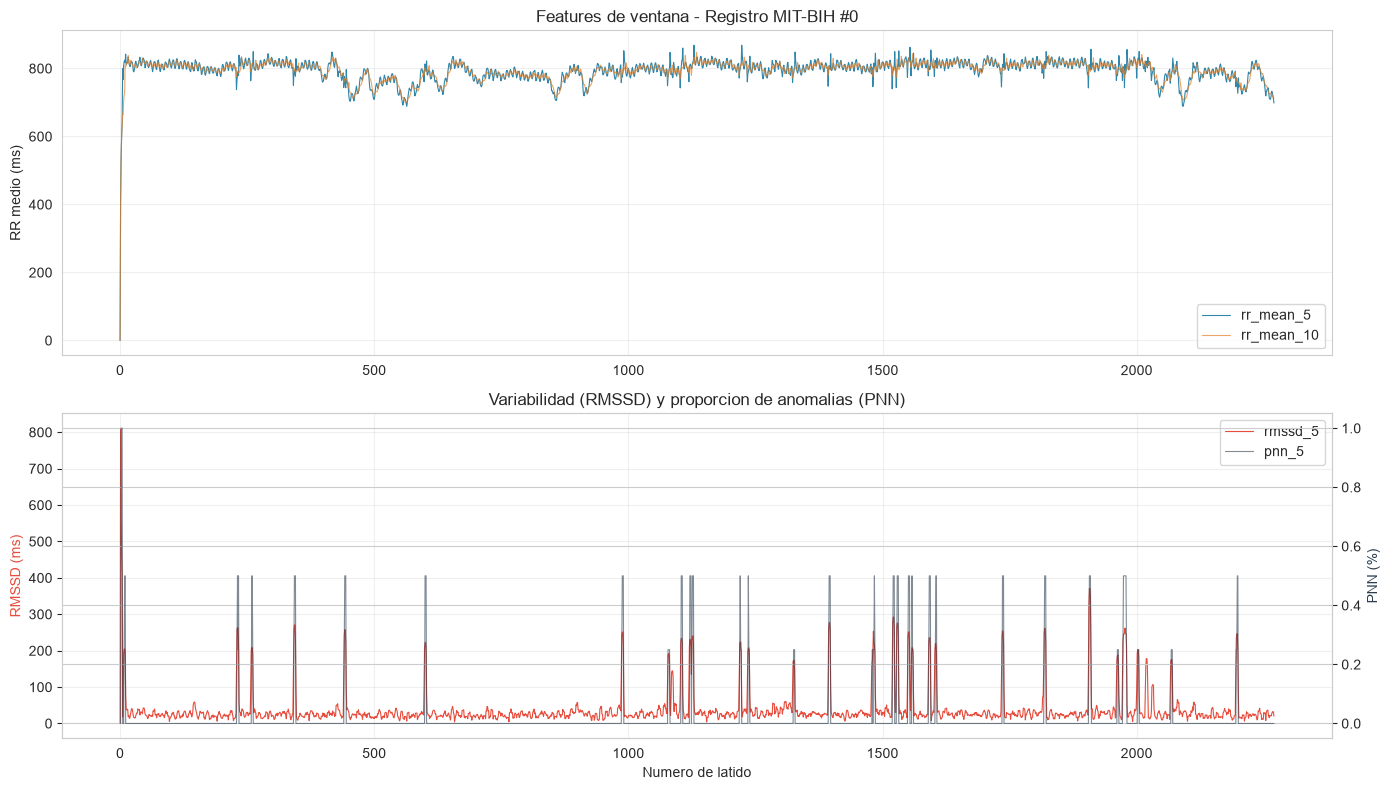

Registro #0: 2271 latidos
RMSSD promedio: 40.23 ms
PNN promedio: 2.09%


In [10]:
# Visualizar features de ventana temporal para un registro con arritmias
from ecg_anomaly.features.manual import (
    ManualFeatureExtractor,
    FEATURE_NAMES,
    WINDOW_FEATURE_NAMES,
)

# Tomar beats del primer registro que tenga al menos 100 latidos
unique_records = np.unique(preprocessed.record_indices)
target_record = None
for rec_id in unique_records:
    mask = preprocessed.record_indices == rec_id
    if np.sum(mask) >= 100:
        target_record = rec_id
        break

mask = preprocessed.record_indices == target_record
n_beats = int(np.sum(mask))
segments_rec = preprocessed.segments[mask]
r_peaks_rec = preprocessed.r_peaks_flat[mask]
record_idx_rec = preprocessed.record_indices[mask]

# Extraer todas las features (incluyendo ventanas), via API publica
extractor = ManualFeatureExtractor()
features_raw = extractor.extract_raw(segments_rec, r_peaks_rec, config.sampling_rate, record_idx_rec)

# Indices de las features de ventana derivados por nombre (no hardcodeados):
# si cambia el orden de FEATURE_NAMES, esto se sigue ajustando solo.
window_cols = [FEATURE_NAMES.index(n) for n in WINDOW_FEATURE_NAMES]
window_feat = features_raw[:, window_cols]

# Graficar
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel 1: RR interval + promedios moviles
axes[0].plot(window_feat[:, 0], color='#2E86AB', linewidth=0.8, label='rr_mean_5')
axes[0].plot(window_feat[:, 2], color='#E67E22', linewidth=0.8, alpha=0.7, label='rr_mean_10')
axes[0].set_ylabel('RR medio (ms)')
axes[0].set_title(f'Features de ventana - Registro MIT-BIH #{int(target_record)}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: RMSSD y PNN
ax2 = axes[1].twinx()
axes[1].plot(window_feat[:, 4], color='#E74C3C', linewidth=0.8, label='rmssd_5')
ax2.plot(window_feat[:, 5], color='#2C3E50', linewidth=0.8, alpha=0.6, label='pnn_5')
axes[1].set_ylabel('RMSSD (ms)', color='#E74C3C')
ax2.set_ylabel('PNN (%)', color='#2C3E50')
axes[1].set_xlabel('Numero de latido')
axes[1].set_title('Variabilidad (RMSSD) y proporcion de anomalias (PNN)')
axes[1].grid(True, alpha=0.3)

# Leyenda combinada
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print(f'Registro #{int(target_record)}: {n_beats} latidos')
print(f'RMSSD promedio: {np.mean(window_feat[:, 4]):.2f} ms')
print(f'PNN promedio: {np.mean(window_feat[:, 5]):.2%}')


## 4. Comparación: PCA vs Características Manuales

Gráfico de dispersión 2D lado a lado de ambas representaciones.

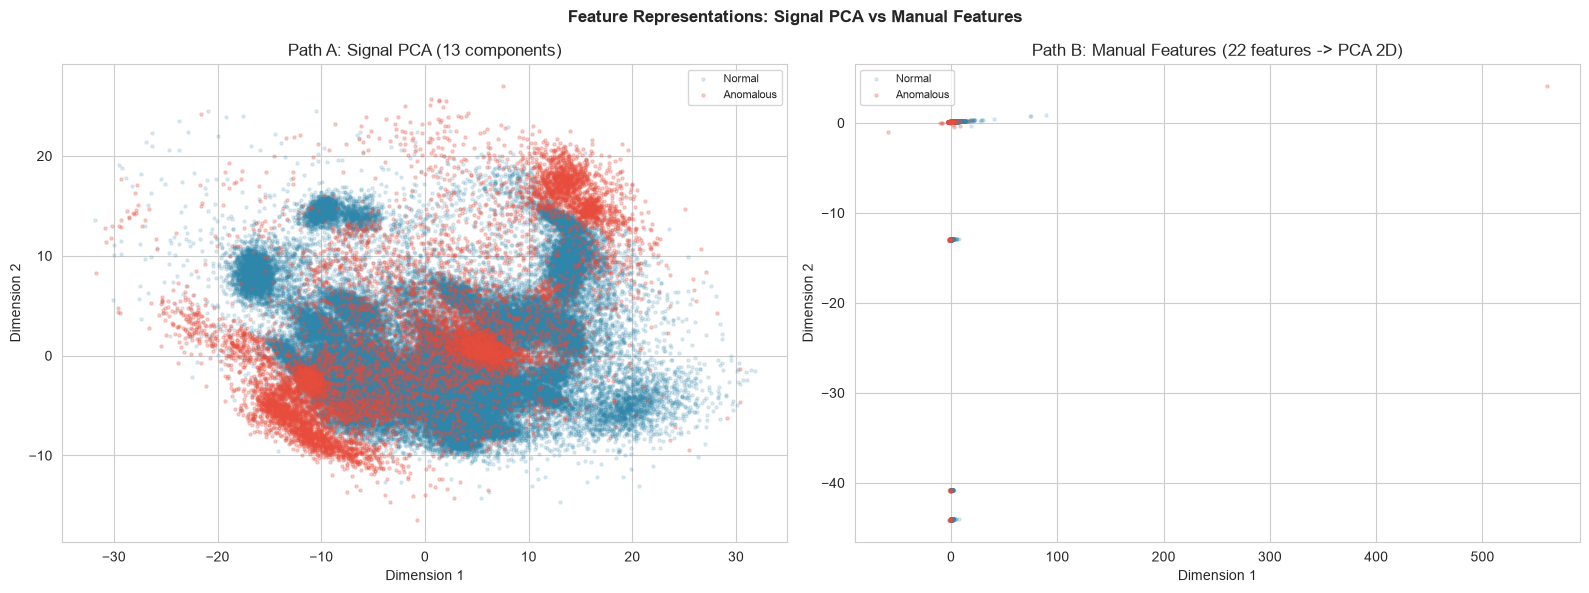

In [11]:
# Apply PCA to manual features for 2D visualization
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_manual_2d = pca_2d.fit_transform(X_manual)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X_2d, title in [
    (axes[0], X_pca[:, :2], f"Path A: Signal PCA ({pca_extractor.n_components} components)"),
    (axes[1], X_manual_2d, f"Path B: Manual Features ({len(FEATURE_NAMES)} features -> PCA 2D)"),
]:
    ax.scatter(X_2d[normal_mask, 0], X_2d[normal_mask, 1], alpha=0.15, s=5, c="#2E86AB", label="Normal")
    ax.scatter(X_2d[anomaly_mask, 0], X_2d[anomaly_mask, 1], alpha=0.25, s=5, c="#E74C3C", label="Anomalous")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Feature Representations: Signal PCA vs Manual Features", fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
# Autoencoder input: scaled signal without PCA
X_autoencoder = pca_extractor.get_raw_for_autoencoder(preprocessed.segments)
print(f"Autoencoder input shape: {X_autoencoder.shape} (full scaled signal, no PCA)")
print(f"Clustering input shape (PCA): {X_pca.shape}")
print(f"Clustering input shape (Manual): {X_manual.shape}")

Autoencoder input shape: (100705, 200) (full scaled signal, no PCA)
Clustering input shape (PCA): (100705, 13)
Clustering input shape (Manual): (100705, 22)


## Resumen

| Representación | Dimensiones | Descripción |
|---|---|---|
| PCA de Señal | ~k (95% var) | Forma de onda directa reducida vía PCA |
| Características Manuales | 22 | 16 base + 6 características de ventana temporal |
| Entrada del Autoencoder | 200 | Señal escalada completa (AE aprende su propia compresión) |

Ambas representaciones muestran cierta separación entre latidos normales y anómalos
en las proyecciones 2D, aunque hay superposición significativa -- consistente
con el desafío de la detección de anomalías no supervisada.

**Siguiente:** `04_clustering.ipynb` -- aplicar los 4 modelos no supervisados.